### NMS

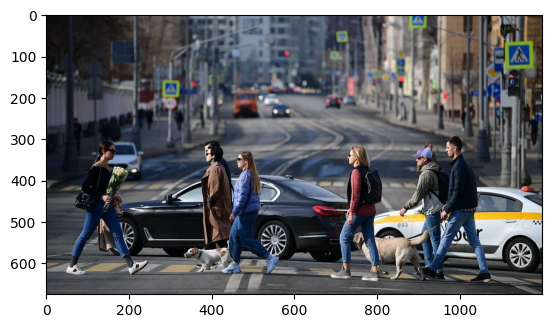

In [35]:
import torch
import matplotlib.pyplot  as plt

from matplotlib.patches import Rectangle
from utils.nms import non_max_suppression
from utils.convert_box import xyxy2xywh
from PIL import Image

img = Image.open('images/00001.jpg').convert('RGB')
pred = torch.load("pred.pt")

plt.imshow(img)
plt.show()

In [36]:
print(pred.shape)

torch.Size([1, 84, 5040])


In [37]:
pr = pred.transpose(-1, -2)
print("pr: ", pr.shape)

all_boxes = pr[..., :4].squeeze()
print("boxes: ", all_boxes.shape)

candidates = pr[..., 4:].amax(dim=2) > 0.25
print(f"candidates: {candidates.shape}, {candidates.dtype}")

cand_boxes = all_boxes[candidates[0]]
print("cand_boxes: ", cand_boxes.shape)

pr:  torch.Size([1, 5040, 84])
boxes:  torch.Size([5040, 4])
candidates: torch.Size([1, 5040]), torch.bool
cand_boxes:  torch.Size([136, 4])


In [38]:
def get_rect(box, color='r'):
    return Rectangle(
                (box[0]-box[2]/2, box[1]-box[3]/2),     # (x, y)
                box[2],        # width
                box[3],        # height
                linewidth=1,
                edgecolor=color,
                facecolor="none"
           )

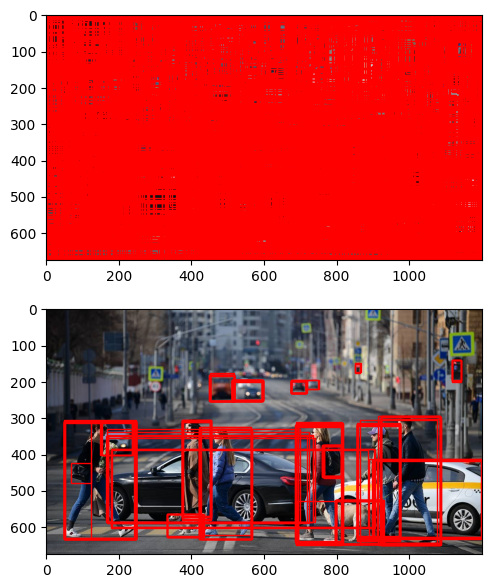

In [39]:
fig, (ax1, ax2) = plt.subplots(2,1)

fig.set_size_inches(12, 7)

ax1.imshow(img)
ax2.imshow(img)

for box in all_boxes:
    rect = get_rect(box)
    ax1.add_patch(rect)

for box in cand_boxes:
    rect = get_rect(box)
    ax2.add_patch(rect)
    
plt.show()


In [6]:
best_boxes_nms = non_max_suppression(pred)[0]
print("non_max_suppression: ", best_boxes_nms.shape)

best_boxes = xyxy2xywh(best_boxes_nms[:, :4])
print("best_boxes: ", best_boxes.shape)

non_max_suppression:  torch.Size([20, 6])
best_boxes:  torch.Size([20, 4])


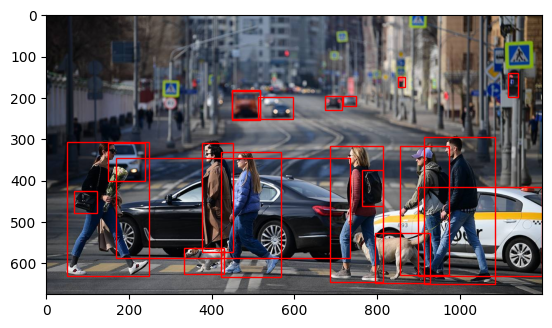

In [7]:
fig, ax = plt.subplots()

ax.imshow(img)

for box in best_boxes:
    rect = get_rect(box)
    ax.add_patch(rect)
    
plt.show()

In [20]:
def plot_boxes(classes, agnostic=False):
    best_boxes_nms = non_max_suppression(pred, classes=classes, agnostic=agnostic)[0]
    best_boxes = xyxy2xywh(best_boxes_nms[:, :4])
    print("num_boxes: ", best_boxes.shape[0])
    fig, ax = plt.subplots()

    ax.imshow(img)

    for box in best_boxes:
        rect = get_rect(box)
        ax.add_patch(rect)
        
    plt.show()

num_boxes:  1


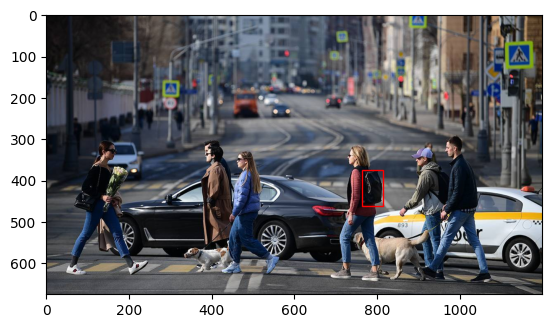

In [38]:
plot_boxes([24], agnostic=True)

### model YOLO_v1

In [205]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, resnet152, regnet_y_800mf, mobilenet_v3_large, efficientnet_v2_l

from models.yolo1 import YOLOv1

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [206]:
device

'cpu'

In [4]:
YOLOv1(num_cl=5, backbone=None, bn=False, act='relu')

YOLOv1(
  (fn_act): ModuleDict(
    (relu): ReLU(inplace=True)
    (leakyrelu): LeakyReLU(negative_slope=0.01, inplace=True)
  )
  (backbone): Backbone(
    (conv1): ConvBA(
      (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (fn_act): ModuleDict(
        (relu): ReLU(inplace=True)
        (leakyrelu): LeakyReLU(negative_slope=0.01, inplace=True)
      )
    )
    (conv2): ConvBA(
      (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (fn_act): ModuleDict(
        (relu): ReLU(inplace=True)
        (leakyrelu): LeakyReLU(negative_slope=0.01, inplace=True)
      )
    )
    (conv3): ConvBlock(
      (conv1x1): ConvBA(
        (conv): Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1))
        (fn_act): ModuleDict(
          (relu): ReLU(inplace=True)
          (leakyrelu): LeakyReLU(negative_slope=0.01, inplace=True)
        )
      )
      (conv3x3): ConvBA(
        (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 

In [6]:
rn18 = resnet18(weights="DEFAULT")
rn152 = resnet152(weights="DEFAULT")
regnet_y = regnet_y_800mf(weights='DEFAULT')
mobilenet = mobilenet_v3_large(weights="DEFAULT")
efficientnet = efficientnet_v2_l(weights="DEFAULT")

backbone_18 = nn.Sequential(
    rn18.conv1,
    rn18.bn1,
    rn18.relu,
    rn18.maxpool,
    rn18.layer1,
    rn18.layer2,
    rn18.layer3,
    rn18.layer4,
)

backbone_152 = nn.Sequential(
    rn152.conv1,
    rn152.bn1,
    rn152.relu,
    rn152.maxpool,
    rn152.layer1,
    rn152.layer2,
    rn152.layer3,
    rn152.layer4,
)

backbone_r = nn.Sequential(
    regnet_y.stem,
    regnet_y.trunk_output    
)

backbone_m = mobilenet.features

backbone_e = efficientnet.features

In [11]:
inp = torch.rand((1, 3, 448, 448)).to(device)
model = YOLOv1(
    num_cl=20,
    backbone=backbone_e,
    bn=True,
    act='relu',
    use_layer='conv3x3',
    use_sigmoid='full_sigmoid'
).to(device)
model.train()
pred = model(inp)
print(f'model.training = {model.training}')
print(f'pred = {pred.shape}')


model.training = True
pred = torch.Size([1, 7, 7, 30])


In [12]:
inp = torch.rand((1, 3, 448, 448)).to(device)
model = YOLOv1(
    num_cl=20,
    backbone=backbone_e,
    bn=True,
    act='relu',
    use_layer='conv3x3',
    use_sigmoid='full_sigmoid'
).to(device)
model.eval()
pred = model(inp)
print(f'model.training = {model.training}')
print(f'pred[0] = {pred[0].shape}')
print(f'pred[1] = {pred[1].shape}')

model.training = False
pred[0] = torch.Size([1, 7, 7, 30])
pred[1] = torch.Size([1, 98, 25])


### Traine Yolo

In [2]:
import os
import random
import torch
import numpy as np
import torch
import torch.nn as nn
import torchvision
from pathlib import Path
from torch.optim import SGD
from torch.optim.lr_scheduler import MultiStepLR
from models.yolo1 import YOLOv1
from utils.dataloaders import create_loader
from utils.nms import nms_yolov1
from utils.general import clip_boxes, process_batch
from loss.loss import YOLOv1Loss
from metrics.metrics import ap_per_class
from tqdm import tqdm

ROOT = Path().resolve()
EPOCHS = 135
BATCH_SIZE = 64
device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 1961
threshold = 0.01
freez_parameters = False
save_dir = ROOT.joinpath('save_model')

r34 = torchvision.models.resnet34(
    weights="DEFAULT"
)

backbone = nn.Sequential(
    r34.conv1,
    r34.bn1,
    r34.relu,
    r34.maxpool,
    r34.layer1,
    r34.layer2,
    r34.layer3,
    r34.layer4,
)

print(f'os_cpu: {os.cpu_count()}')
print(f'cuda: {torch.cuda.device_count()}')
print(ROOT)

os_cpu: 4
cuda: 0
D:\Sergey\Courses\objectDetection\Progect\objectDetection


In [10]:
pascal_voc_val = torchvision.datasets.VOCDetection(
    root=ROOT.joinpath('datasets'),
    year='2012',
    image_set='trainval',
    download=True
)

pascal_voc_val = torchvision.datasets.VOCDetection(
    root=ROOT.joinpath('datasets'),
    year='2007',
    image_set='trainval',
    download=True
)

100%|██████████| 1999639040/1999639040 [02:55<00:00, 11415060.24it/s]


Extracting D:\Sergey\Courses\objectDetection\Progect\objectDetection\datasets\VOCtrainval_11-May-2012.tar to D:\Sergey\Courses\objectDetection\Progect\objectDetection\datasets


100%|██████████| 460032000/460032000 [00:43<00:00, 10641991.09it/s]


Extracting D:\Sergey\Courses\objectDetection\Progect\objectDetection\datasets\VOCtrainval_06-Nov-2007.tar to D:\Sergey\Courses\objectDetection\Progect\objectDetection\datasets


In [ ]:
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if device == 'cuda':
    torch.cuda.manual_seed_all(seed)

print('Подготовка данных.')
train_loader, val_loader = create_loader(
    [
        ROOT.joinpath('datasets/VOCdevkit/VOC2012'),
        ROOT.joinpath('datasets/VOCdevkit/VOC2007'),
        ROOT.joinpath('datasets/VOCdevkit/VOC22')
    ],
    split=[0.8, 0.2],
    batch_size=BATCH_SIZE,
    workers=1,
    pin_memory=True,
    shuffle_train=True
)
print('Подготовка модели, оптимизатора и scheduler.')
model = YOLOv1(
    backbone=backbone,
    use_layer='conv1x1',
    use_sigmoid='not_full_sigmoid'
)
model.to(device)
if freez_parameters:
    for param in model.backbone.parameters():
        param.requires_grad = False
loss_model = YOLOv1Loss()
opt = SGD(
    params=model.parameters(),
    lr=0.001,
    weight_decay=5e-4,
    momentum=0.9
)
lr_scheduler = MultiStepLR(
    opt,
    milestones=[75, 105],
    gamma=0.5
)

if not save_dir.exists():
    os.mkdir(save_dir)

train_loss, val_loss, lr_list, metrics, best_loss = [], [], [], [], None

print('Старт цикла обучения')
# ===== start training =====
for epoch in range(EPOCHS):
    # ===== start epoch =====
    model.train()
    loss_f = []
    train_loop = tqdm(train_loader, leave=False)
    for img, targets, _ in train_loop:
        # ===== start train batch =====
        # images + targets
        img = img.to(device, non_blocking=True)    # size (batch_size, 3, 448, 448)
        targets = targets.to(device, non_blocking=True)    # size (batch_size, S, S, 5*B+num_class)

        # Forward
        preds = model(img)    # size (batch_size, S, S, 5*B+num_class)

        loss, *loss_list = loss_model(preds, targets)

        # Backward
        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_f.append(loss_list)
        loss_list = np.array(loss_f).mean(axis=0)

        train_loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}], train_loss={loss_list[0]:.4f}, x_loss={loss_list[1]:.4f}, y_loss={loss_list[2]:.4f}, w_loss={loss_list[3]:.4f}, h_loss={loss_list[4]:.4f}, conf_loss={loss_list[5]:.4f}, class_loss={loss_list[6]:.4f}, no_obj_conf_loss={loss_list[7]:.4f}")

        # ===== end train batch =====

    # Сохранение значения функции потерь
    train_loss.append(loss_list[0])

    model.eval()
    with torch.no_grad():
        loss_f = []
        stats = []
        # Вектор cо значениями метрики IoU для расчёта метрики mAP с разными порогами.
        iouv = torch.linspace(0.5, 0.95, 10, device=device)
        niou = iouv.numel()
        for img, targets, boxes_classes in val_loader:
            # ===== start val batch =====
            # images + targets
            img = img.to(device, non_blocking=True)    # size (batch_size, 3, 448, 448)
            targets = targets.to(device, non_blocking=True)    # size (batch_size, S, S, 5*B+num_class)

            # Forward в режиме model.eval
            # preds => (batch_size, S, S, 5*B+num_class)
            # boxes_conf_class => (batch_size, S*S*B, 5+num_class)
            preds, boxes_conf_class = model(img)
            loss, *loss_list = loss_model(preds, targets)

            preds_nms = nms_yolov1(boxes_conf_class, 0.25, 0.45)

            # Metrics
            for idx, pred in enumerate(preds_nms):
                labels = boxes_classes[idx].to(device)
                # Кол-во реальных объектов на изображении и кол-во предсказанных.
                nl, npr = labels.shape[0], pred.shape[0]
                correct = torch.zeros(npr, niou, dtype=torch.bool, device=device)

                if npr == 0:
                    if nl:
                        stats.append((correct, *torch.zeros((2, 0), device=device), labels[:, 4]))
                    continue

                predn = pred.clone()

                if nl:
                    tbox = labels[:, :4]  # target boxes
                    clip_boxes(tbox)
                    labelsn = torch.cat((labels[:, 4:], tbox), 1)  # native-space labels
                    correct = process_batch(predn, labelsn, iouv)
                stats.append((correct, pred[:, 4], pred[:, 5], labels[:, 4]))  # (correct, conf, pcls, tcls)


            loss_f.append(loss_list)

            # ===== end val batch =====

    # Подсчёт метрики.
    stats = [torch.cat(x, 0).cpu().numpy() for x in zip(*stats)]  # to numpy
    if len(stats) and stats[0].any():
        ap = ap_per_class(*stats)
        ap50, ap = ap[:, 0], ap.mean(1)  # AP@0.5, AP@0.5:0.95
        map50, mAP = ap50.mean(), ap.mean()  # mAP@0.5, mAP@0.5:0.95
        metrics.append((map50, mAP))
        print(f'Epoch [{epoch+1}/{EPOCHS}]: mAP@0.5 = {map50:.4f}, mAP@0.5:0.95 = {mAP:.4f}')
    else:
        print(f"Epoch [{epoch+1}/{EPOCHS}]: метрика не расчитывалась.")

    loss_list = np.array(loss_f).mean(axis=0)

    print(f"Epoch [{epoch+1}/{EPOCHS}], train_loss={train_loss[-1]:.4f}, val_loss={loss_list[0]:.4f}, x_loss={loss_list[1]:.4f}, y_loss={loss_list[2]:.4f}, w_loss={loss_list[3]:.4f}, h_loss={loss_list[4]:.4f}, conf_loss={loss_list[5]:.4f}, class_loss={loss_list[6]:.4f}, no_obj_conf_loss={loss_list[7]:.4f}")

    # Сохранение значения функции потерь и метрики
    val_loss.append(loss_list[0])

    lr_scheduler.step()
    lr = lr_scheduler.get_last_lr()
    lr_list.append(lr)

    if best_loss is None:
        best_loss = val_loss[-1]

    if best_loss - best_loss*threshold > val_loss[-1]:
        best_loss = val_loss[-1]
        
        checkpoint = {
            'state_model': model.state_dict(),
            'state_opt': opt.state_dict(),
            'state_lr_scheduler': lr_scheduler.state_dict(),
            'loss': {
                'train_loss': train_loss,
                'val_loss': val_loss
            },
            'metrics': metrics,
            'lr': lr_list,
            'save_epoch': epoch
        }

        torch.save(checkpoint, save_dir.joinpath('model_state_dict.pt'))
        print(f'На эпохе - {epoch+1}, сохранена модель со значением функции потерь на валидации - {val_loss[-1]:.4f}', end='\n\n')

    # ===== end epoch =====

# ===== end training =====
checkpoint = {
    'state_model': model.state_dict(),
    'state_opt': opt.state_dict(),
    'state_lr_scheduler': lr_scheduler.state_dict(),
    'loss': {
        'train_loss': train_loss,
        'val_loss': val_loss
    },
    'metrics': metrics,
    'lr': lr_list,
    'save_epoch': epoch
}

torch.save(checkpoint, save_dir.joinpath('model_state_dict_finish.pt'))
print(f'На эпохе - {epoch+1}, сохранена финальная модель со значением функции потерь на валидации - {val_loss[-1]:.4f}', end='\n\n')
print(f'Обучение длилось {EPOCHS} эпох.')

Подготовка данных
В наборе данных 22136 размеченных изображений.
Подготовка модели, оптимизатора и scheduler.
Старт цикла обучения
Epoch [1/135]: mAP@0.5 = 0.1323, mAP@0.5:0.95 = 0.0383
Epoch [1/135], train_loss=3.6247, val_loss=2.8185, x_loss=0.1338, y_loss=0.1288, w_loss=0.0366, h_loss=0.0338, conf_loss=0.2454, class_loss=0.7908, no_obj_conf_loss=0.2351
Epoch [2/135]: mAP@0.5 = 0.4009, mAP@0.5:0.95 = 0.1305
Epoch [2/135], train_loss=2.5790, val_loss=2.4877, x_loss=0.1210, y_loss=0.1139, w_loss=0.0323, h_loss=0.0279, conf_loss=0.2405, class_loss=0.6605, no_obj_conf_loss=0.2218
Epoch [3/135]: mAP@0.5 = 0.4526, mAP@0.5:0.95 = 0.1638
Epoch [3/135], train_loss=2.3446, val_loss=2.3233, x_loss=0.1157, y_loss=0.1038, w_loss=0.0304, h_loss=0.0271, conf_loss=0.2081, class_loss=0.6166, no_obj_conf_loss=0.2272
Epoch [4/135]: mAP@0.5 = 0.4996, mAP@0.5:0.95 = 0.1992
Epoch [4/135], train_loss=2.1730, val_loss=2.2146, x_loss=0.1089, y_loss=0.0997, w_loss=0.0278, h_loss=0.0247, conf_loss=0.1966, clas

In [ ]:
import matplotlib.pyplot  as plt
from matplotlib.patches import Rectangle
import numpy as np
from utils.dataloaders import PascalVOC, DatasetPascalVOCYOLOv1
from utils.nms import nms_yolov1
from utils.bbox_iou import iou
from PIL import Image

def get_rect(box, color='r'):
    return Rectangle(
                (box[0], box[1]),     # (x, y)
                box[2]-box[0],        # width
                box[3]-box[1],        # height
                linewidth=1,
                edgecolor=color,
                facecolor="none"
            )

model = YOLOv1(
    backbone=backbone,
    use_layer='conv1x1',
    use_sigmoid='not_full_sigmoid'
)
model.to(device)
state_dict = torch.load(save_dir.joinpath('model_state_dict.pt'), map_location=device)
model.load_state_dict(state_dict['state_model'])

data = PascalVOC([ROOT.joinpath('datasets/VOCdevkit/VOC2007')]).create_data()

В наборе данных 5011 размеченных изображений.


tensor([[0.0335, 0.0759, 0.9911, 0.9464, 9.0000]])
tensor([[0.0394, 0.0617, 0.9743, 0.9657, 0.9005, 9.0000]],
       grad_fn=<IndexBackward0>)
(500, 375, 3)


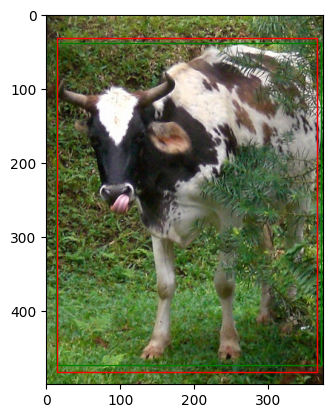

In [86]:
idx_img = np.random.randint(0, 1000)
# img, _, boxes_classes = val_set[idx_img]
d = data[idx_img]
w, h = d['size_img']
img, _, boxes_classes = DatasetPascalVOCYOLOv1([d], mode='test')[0]
img = img.unsqueeze(dim=0).to(device)

model.eval()
_, boxes_conf_classes = model(img)

pred_bcl = nms_yolov1(boxes_conf_classes, 0.2, 0.45)

print(boxes_classes)
print(pred_bcl[0])

np_f = Path(d['path_img']).with_suffix(".npy")
img_n = np.load(np_f)

print(img_n.shape)

imgn = img_n#*[0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]

fig, ax = plt.subplots()

ax.imshow(imgn)

for box in boxes_classes:
    box = box.detach().to('cpu') * torch.tensor([w, h, w, h, 1])
    rect = get_rect(box, color='g')
    ax.add_patch(rect)

for box in pred_bcl[0]:
    box = box.detach().to('cpu')*torch.tensor([w, h, w, h, 1, 1])
    rect = get_rect(box, color='r')
    ax.add_patch(rect)

plt.show()